## Notebook 03 — Descriptive Visualisation

Project: Ten-Year Haemoglobin Genotype Surveillance in a Nigerian University Cohort (Bowen University, 2015–2024, n = 8,890)

### Purpose

This notebook generates the descriptive figures used to visualise cohort composition across the study period, including genotype distributions by year, clinical-category trends, sex distributions, and an overall study summary panel. All figures are generated from tables produced in Notebook 02, preserving a traceable path from the processed analytical dataset to each published figure.

### Outputs

The notebook produces:

* Distribution figures across the cohort, by year, and by sex
* A composition figure for the carrier population (HbAS and HbAC) across the decade
* A composite study-summary panel

All figures are exported to `outputs/figures/` as 300 DPI PNG and vector PDF files using the naming convention defined in the project codebase.


## Cell 1 - Environment and shared settings

In [11]:
# Cell 1: Environment and shared settings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans", "sans-serif"],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

GENO_COLOR = {
    "AA": "#1f77b4", "AC": "#2ca02c", "AS": "#ff7f0e",
    "CC": "#8c564b", "SC": "#9467bd", "SS": "#d62728",
}
CLIN_COLOR = {"Normal": "#1f77b4", "Carrier": "#ff7f0e", "Disease": "#d62728"}
SEX_COLOR  = {"Male": "#1f77b4", "Female": "#ff7f0e"}

GENO_ORDER = ["AA", "AC", "AS", "CC", "SC", "SS"]
CLIN_ORDER = ["Carrier", "Disease", "Normal"]
YEARS = list(range(2015, 2025))

print("Environment ready.")

Environment ready.


## Cell 2 - Load tables produced by Notebook 02

In [12]:
# Cell 2: Each figure reads from one of these tables; provenance is explicit.
geno_overall  = pd.read_csv(TABLES / "02_genotype_distribution_overall.csv", index_col=0)
geno_pct_year = pd.read_csv(TABLES / "02_genotype_percentages_by_year.csv", index_col=0)
clin_pct_year = pd.read_csv(TABLES / "02_clinical_category_percentages_by_year.csv",
                            index_col=0)
sex_pct_year  = pd.read_csv(TABLES / "02_sex_percentages_by_year.csv", index_col=0)
geno_pct_sex  = pd.read_csv(TABLES / "02_genotype_percentages_by_sex.csv", index_col=0)
clin_pct_sex  = pd.read_csv(TABLES / "02_clinical_category_percentages_by_sex.csv",
                            index_col=0)
clin_overall  = pd.read_csv(TABLES / "02_clinical_category_distribution_overall.csv",
                            index_col=0)
print("Tables loaded.")

Tables loaded.


## Cell 3 - Saving helper

In [13]:
# Cell 3: Save each figure as 300 DPI PNG and vector PDF
def save_figure(fig, name):
    fig.savefig(FIGURES / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES / f"{name}.pdf", bbox_inches="tight")
    print(f"Saved: outputs/figures/{name}.png and .pdf")

## Cell 4 - Genotype Distribution by Year

Saved: outputs/figures/genotype_distribution_by_year.png and .pdf


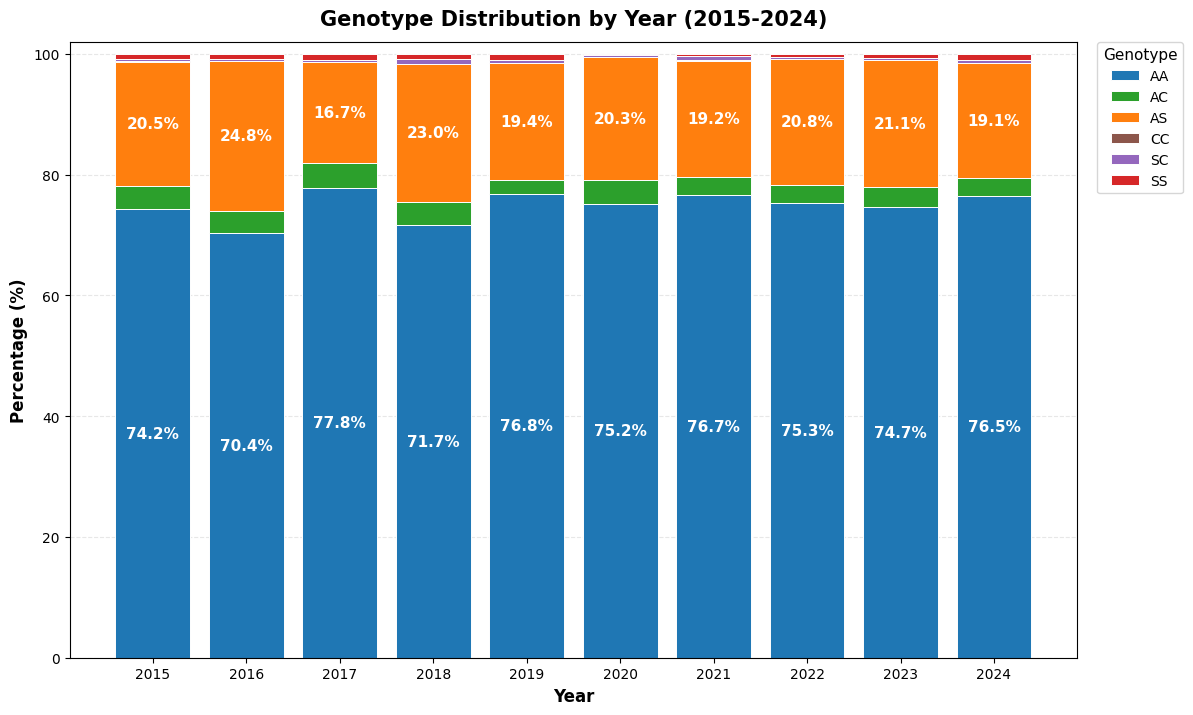

In [14]:
# Cell 4: genotype_distribution_by_year.png
fig, ax = plt.subplots(figsize=(13, 8))

data = geno_pct_year[GENO_ORDER]
bottom = np.zeros(len(data))
for g in GENO_ORDER:
    vals = data[g].values
    ax.bar(data.index.astype(str), vals, bottom=bottom,
           color=GENO_COLOR[g], edgecolor="white", linewidth=0.7, label=g)
    if g in ("AA", "AS"):
        for i, v in enumerate(vals):
            ax.text(i, bottom[i] + v / 2, f"{v:.1f}%",
                    ha="center", va="center", color="white",
                    fontsize=11, fontweight="bold")
    bottom += vals

ax.set_title("Genotype Distribution by Year (2015-2024)", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 102)
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
ax.legend(title="Genotype", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

save_figure(fig, "genotype_distribution_by_year")
plt.show()

## Cell 5 - Genotype Distribution by Sex

Saved: outputs/figures/genotype_distribution_by_sex.png and .pdf


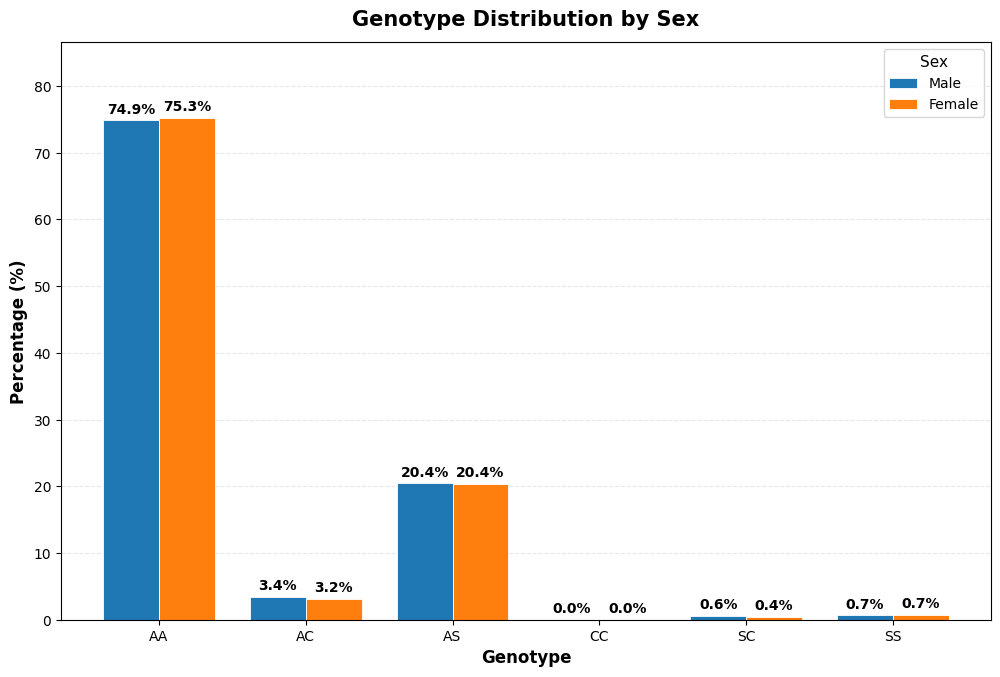

In [15]:
# Cell 5: genotype_distribution_by_sex.png (grouped bars, Male first then Female)
fig, ax = plt.subplots(figsize=(12, 7.5))

g = geno_pct_sex.reindex(GENO_ORDER)
x = np.arange(len(g.index))
width = 0.38

bars_m = ax.bar(x - width/2, g["M"], width, color=SEX_COLOR["Male"],
                edgecolor="white", linewidth=0.6, label="Male")
bars_f = ax.bar(x + width/2, g["F"], width, color=SEX_COLOR["Female"],
                edgecolor="white", linewidth=0.6, label="Female")

for bars in (bars_m, bars_f):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.6,
                f"{h:.1f}%", ha="center", va="bottom",
                fontsize=10, fontweight="bold")

ax.set_title("Genotype Distribution by Sex", pad=12)
ax.set_xlabel("Genotype")
ax.set_ylabel("Percentage (%)")
ax.set_xticks(x)
ax.set_xticklabels(g.index)
ax.set_ylim(0, max(g.max()) * 1.15)
ax.legend(title="Sex", loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

save_figure(fig, "genotype_distribution_by_sex")
plt.show()

## Cell 6 - Clinical Category Distribution by Year

Saved: outputs/figures/clinical_category_distribution_by_year.png and .pdf


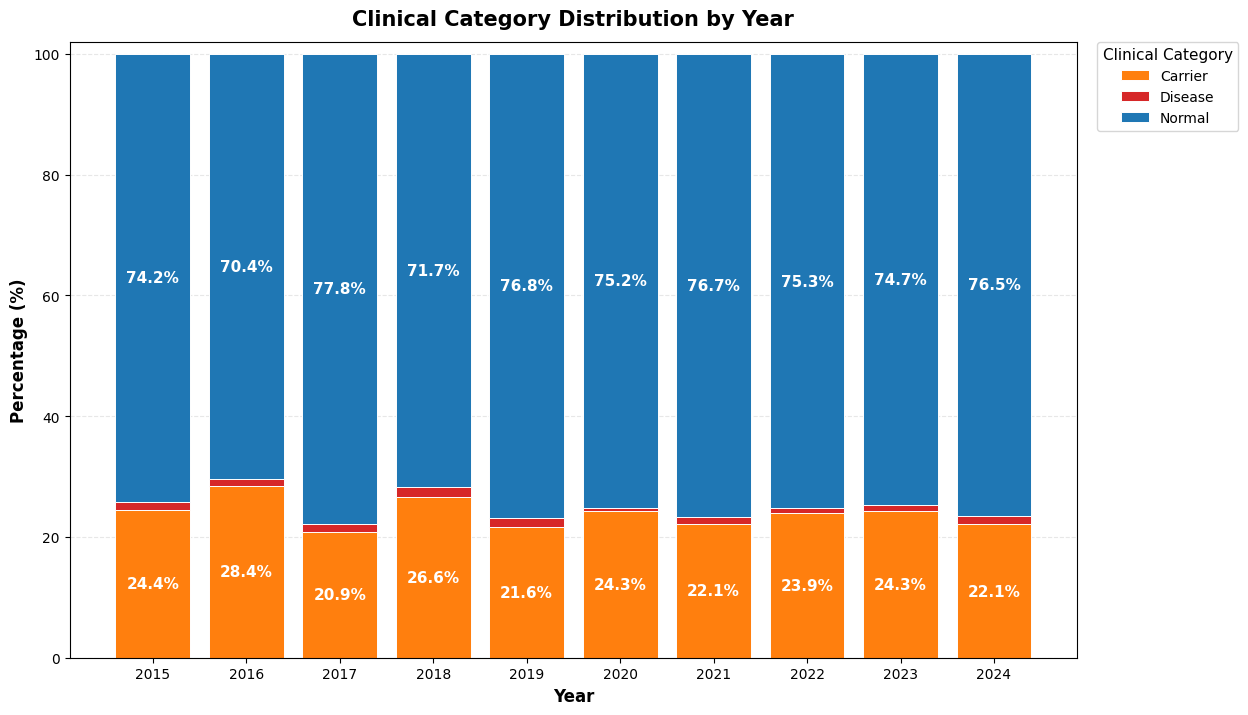

In [16]:
# Cell 6: clinical_category_distribution_by_year.png
fig, ax = plt.subplots(figsize=(13, 8))

clin = clin_pct_year[CLIN_ORDER]
bottom = np.zeros(len(clin))
for c in CLIN_ORDER:
    vals = clin[c].values
    ax.bar(clin.index.astype(str), vals, bottom=bottom,
           color=CLIN_COLOR[c], edgecolor="white", linewidth=0.7, label=c)
    if c in ("Carrier", "Normal"):
        for i, v in enumerate(vals):
            ax.text(i, bottom[i] + v / 2, f"{v:.1f}%",
                    ha="center", va="center", color="white",
                    fontsize=11, fontweight="bold")
    bottom += vals

ax.set_title("Clinical Category Distribution by Year", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 102)
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
ax.legend(title="Clinical Category", bbox_to_anchor=(1.02, 1), loc="upper left",
          borderaxespad=0)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

save_figure(fig, "clinical_category_distribution_by_year")
plt.show()

## Cell 7 - Clinical Category Distribution by Sex

Saved: outputs/figures/clinical_category_distribution_by_sex.png and .pdf


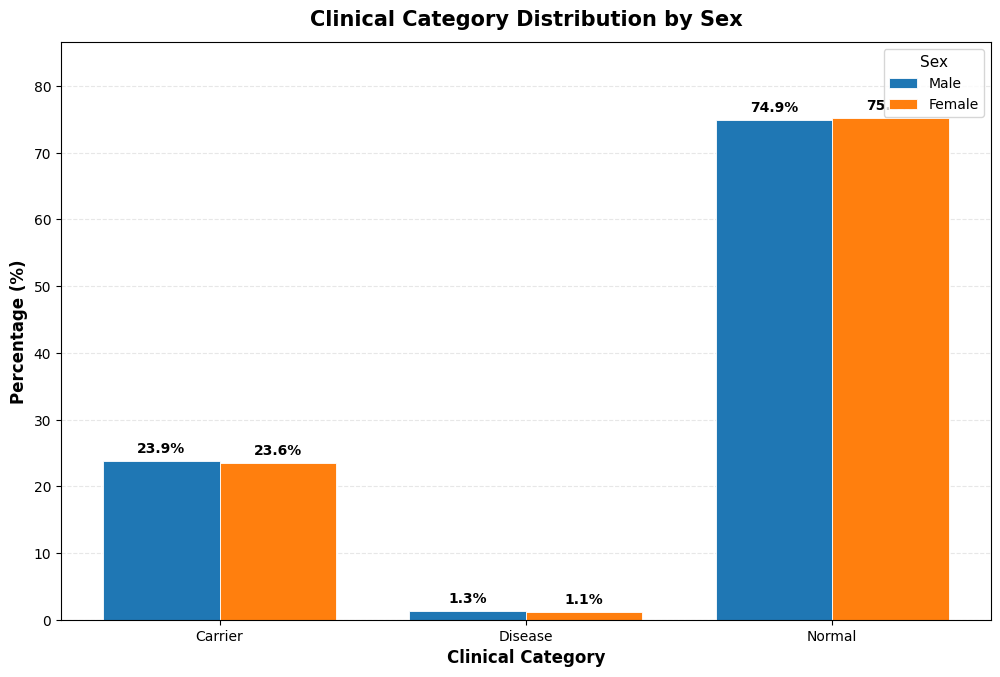

In [17]:
# Cell 7: clinical_category_distribution_by_sex.png (grouped bars)
fig, ax = plt.subplots(figsize=(12, 7.5))

c = clin_pct_sex.reindex(CLIN_ORDER)
x = np.arange(len(c.index))
width = 0.38

bars_m = ax.bar(x - width/2, c["M"], width, color=SEX_COLOR["Male"],
                edgecolor="white", linewidth=0.6, label="Male")
bars_f = ax.bar(x + width/2, c["F"], width, color=SEX_COLOR["Female"],
                edgecolor="white", linewidth=0.6, label="Female")

for bars in (bars_m, bars_f):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f"{h:.1f}%", ha="center", va="bottom",
                fontsize=10, fontweight="bold")

ax.set_title("Clinical Category Distribution by Sex", pad=12)
ax.set_xlabel("Clinical Category")
ax.set_ylabel("Percentage (%)")
ax.set_xticks(x)
ax.set_xticklabels(c.index)
ax.set_ylim(0, max(c.max()) * 1.15)
ax.legend(title="Sex", loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

save_figure(fig, "clinical_category_distribution_by_sex")
plt.show()

## Cell 8 - Gender Distribution by Year

Saved: outputs/figures/gender_distribution_by_year.png and .pdf


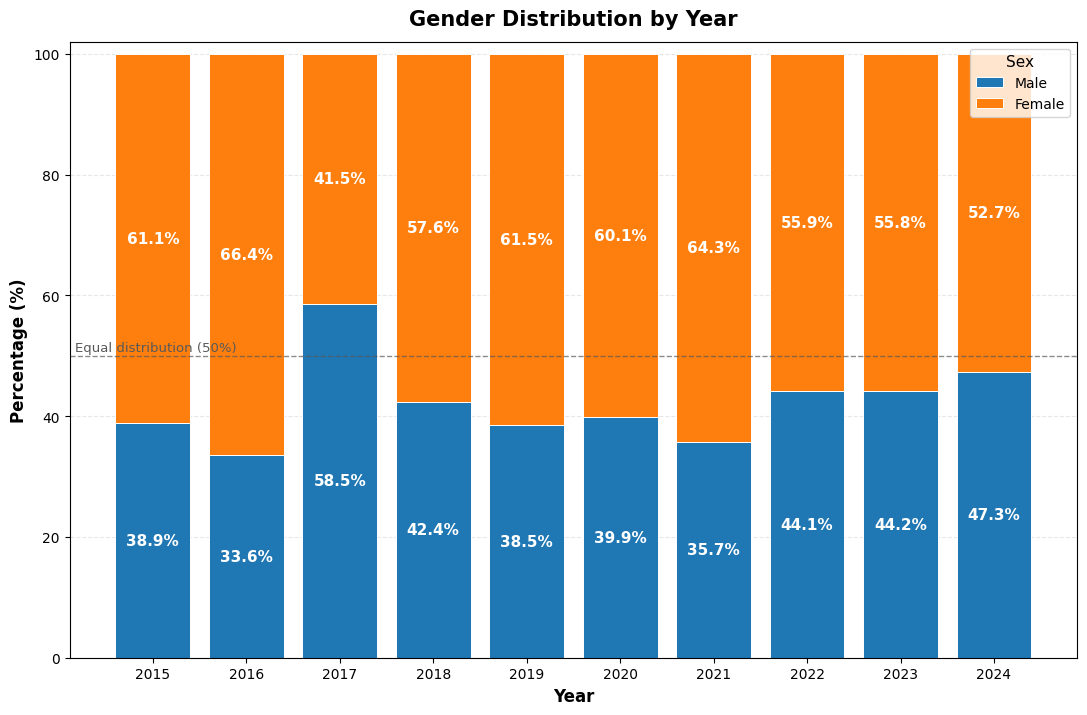

In [18]:
# Cell 8: gender_distribution_by_year.png (stacked Male/Female with 50% parity line)
fig, ax = plt.subplots(figsize=(13, 8))

sx = sex_pct_year[["Male", "Female"]]
bottom = np.zeros(len(sx))
for s in ["Male", "Female"]:
    vals = sx[s].values
    ax.bar(sx.index.astype(str), vals, bottom=bottom,
           color=SEX_COLOR[s], edgecolor="white", linewidth=0.7, label=s)
    for i, v in enumerate(vals):
        ax.text(i, bottom[i] + v / 2, f"{v:.1f}%",
                ha="center", va="center", color="white",
                fontsize=11, fontweight="bold")
    bottom += vals

ax.axhline(50, color="0.35", linestyle="--", linewidth=1.0, alpha=0.7)
ax.text(0.005, 50.8, "Equal distribution (50%)", color="0.35", fontsize=9.5,
        transform=ax.get_yaxis_transform())

ax.set_title("Gender Distribution by Year", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 102)
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
ax.legend(title="Sex", loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

save_figure(fig, "gender_distribution_by_year")
plt.show()

## Cell 9 - Carrier Genotype Composition Over Time

Saved: outputs/figures/carrier_rate_composition.png and .pdf


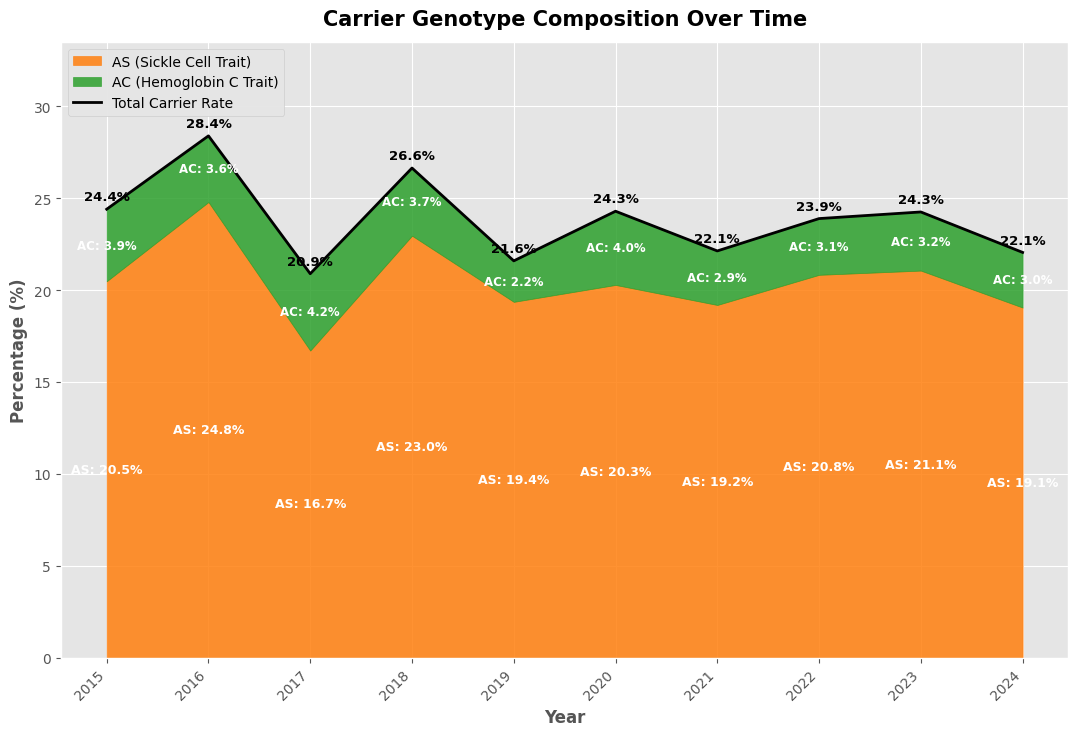

In [19]:
# Cell 9: carrier_rate_composition.png (stacked area chart, ggplot grey background)
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(13, 8))

    as_pct = geno_pct_year["AS"].reindex(YEARS).values
    ac_pct = geno_pct_year["AC"].reindex(YEARS).values
    total  = as_pct + ac_pct

    ax.fill_between(YEARS, 0, as_pct, color=GENO_COLOR["AS"],
                    alpha=0.85, label="AS (Sickle Cell Trait)")
    ax.fill_between(YEARS, as_pct, as_pct + ac_pct, color=GENO_COLOR["AC"],
                    alpha=0.85, label="AC (Hemoglobin C Trait)")
    ax.plot(YEARS, total, color="black", linewidth=2.0, label="Total Carrier Rate")

    for i, y in enumerate(YEARS):
        ax.text(y, as_pct[i] / 2, f"AS: {as_pct[i]:.1f}%",
                ha="center", va="center", color="white", fontsize=9, fontweight="bold")
        ax.text(y, as_pct[i] + ac_pct[i] / 2, f"AC: {ac_pct[i]:.1f}%",
                ha="center", va="center", color="white", fontsize=8.5, fontweight="bold")
        ax.text(y, total[i] + 0.3, f"{total[i]:.1f}%",
                ha="center", va="bottom", color="black", fontsize=9.5, fontweight="bold")

    ax.set_title("Carrier Genotype Composition Over Time", pad=12, fontsize=15,
                 fontweight="bold")
    ax.set_xlabel("Year", fontsize=12, fontweight="bold")
    ax.set_ylabel("Percentage (%)", fontsize=12, fontweight="bold")
    ax.set_xticks(YEARS)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_ylim(0, max(total) * 1.18)
    ax.legend(loc="upper left", framealpha=0.95)

    save_figure(fig, "carrier_rate_composition")
    plt.show()

## Cell 10 - Comprehensive Study Summary (composite panel)

A four-panel summary used as a single-glance overview of the study: overall clinical
category composition, average sex distribution, the disease-genotype trajectory across
years, and a numeric summary table.

Saved: outputs/figures/study_summary.png and .pdf


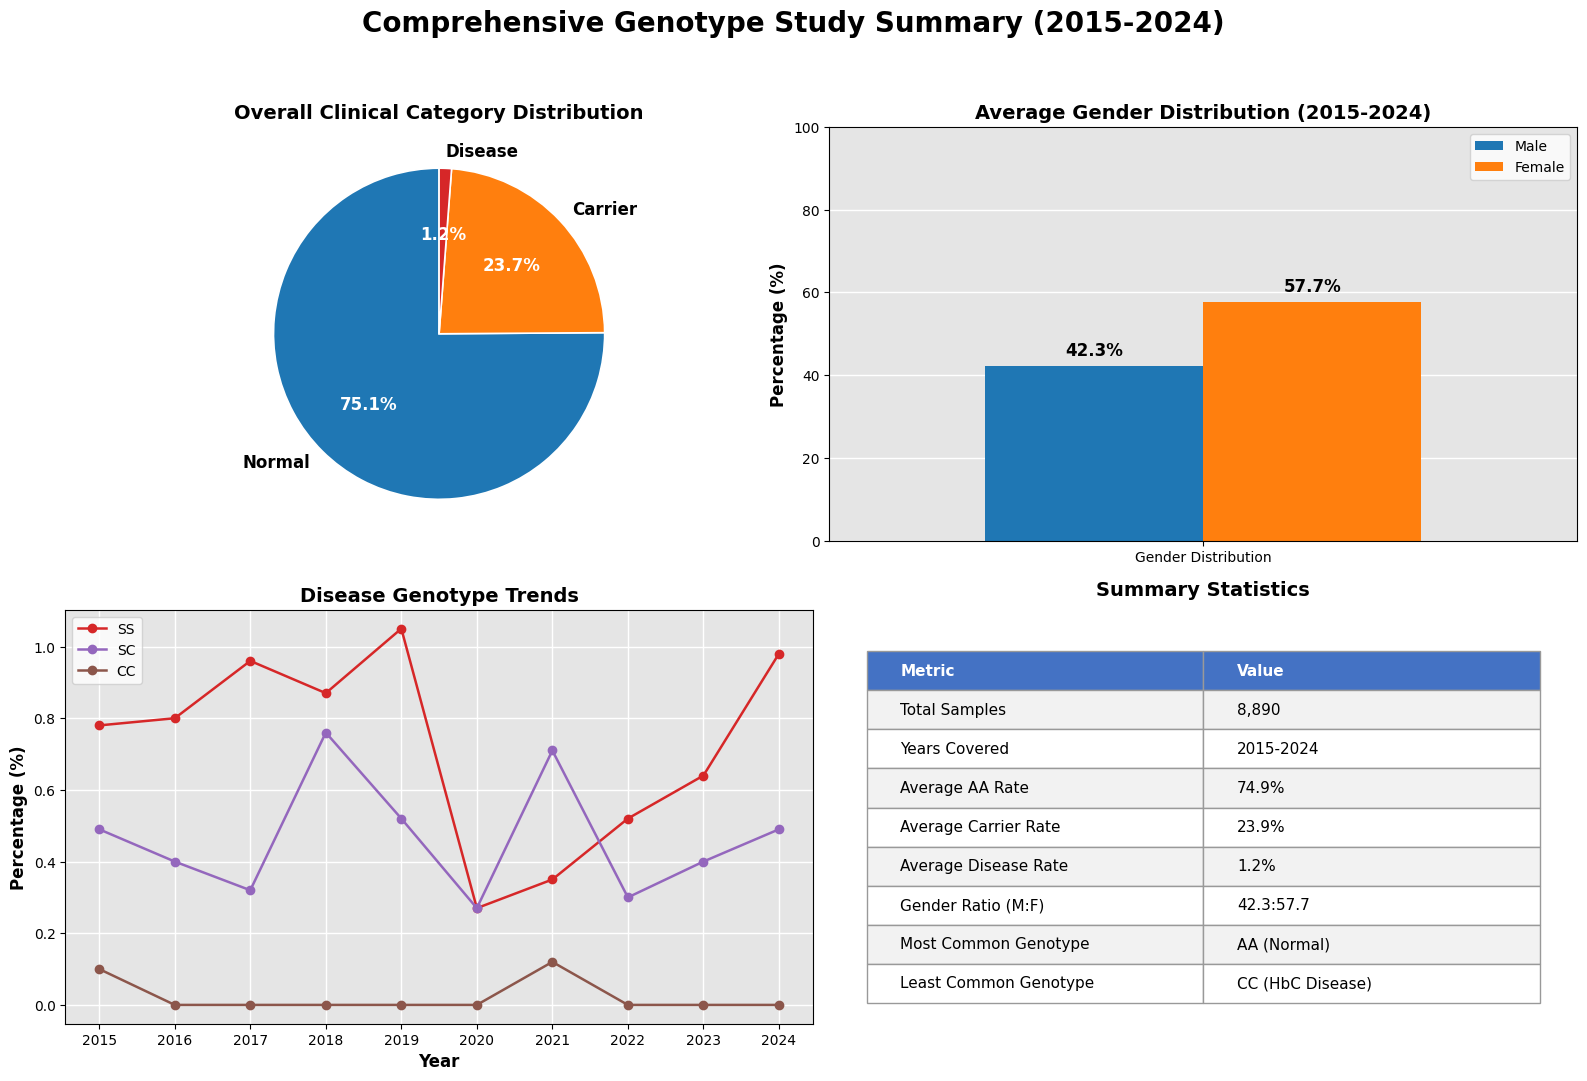

In [20]:
# Cell 10: study_summary.png (2x2 composite)
fig = plt.figure(figsize=(16, 11))
fig.suptitle("Comprehensive Genotype Study Summary (2015-2024)",
             fontsize=20, fontweight="bold", y=0.98)

# Panel A: overall clinical category pie
axA = fig.add_subplot(2, 2, 1)
clin_o = clin_overall.reindex(["Normal", "Carrier", "Disease"])
colors_pie = [CLIN_COLOR[k] for k in clin_o.index]
wedges, texts, autotexts = axA.pie(
    clin_o["Count"], labels=clin_o.index, colors=colors_pie,
    autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 12, "fontweight": "bold"},
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
)
for at in autotexts:
    at.set_color("white")
    at.set_fontweight("bold")
axA.set_title("Overall Clinical Category Distribution", fontsize=14, fontweight="bold")

# Panel B: average sex distribution (two side-by-side bars)
axB = fig.add_subplot(2, 2, 2)
axB.set_facecolor("#e5e5e5")
sex_avg = sex_pct_year.mean()
m_avg, f_avg = sex_avg["Male"], sex_avg["Female"]

width = 0.35
axB.bar(-width/2, m_avg, width=width, color=SEX_COLOR["Male"], label="Male")
axB.bar( width/2, f_avg, width=width, color=SEX_COLOR["Female"], label="Female")

axB.text(-width/2, m_avg + 1.5, f"{m_avg:.1f}%", ha="center", va="bottom",
         fontsize=12, fontweight="bold")
axB.text( width/2, f_avg + 1.5, f"{f_avg:.1f}%", ha="center", va="bottom",
         fontsize=12, fontweight="bold")

axB.set_xticks([0])
axB.set_xticklabels(["Gender Distribution"])
axB.set_xlim(-0.6, 0.6)
axB.set_ylim(0, 100)
axB.set_ylabel("Percentage (%)")
axB.set_title("Average Gender Distribution (2015-2024)", fontsize=14, fontweight="bold")
axB.legend(loc="upper right")
axB.grid(axis="y", color="white", linewidth=1)
axB.set_axisbelow(True)

# Panel C: disease genotypes over time
axC = fig.add_subplot(2, 2, 3)
axC.set_facecolor("#e5e5e5")
for g in ["SS", "SC", "CC"]:
    axC.plot(YEARS, geno_pct_year[g].reindex(YEARS).values,
             marker="o", linewidth=1.8, markersize=6, color=GENO_COLOR[g], label=g)
axC.set_title("Disease Genotype Trends", fontsize=14, fontweight="bold")
axC.set_xlabel("Year")
axC.set_ylabel("Percentage (%)")
axC.set_xticks(YEARS)
plt.setp(axC.get_xticklabels(), rotation=0)
axC.legend(loc="upper left", title=None)
axC.grid(True, color="white", linewidth=1)
axC.set_axisbelow(True)

# Panel D: summary statistics table
axD = fig.add_subplot(2, 2, 4)
axD.axis("off")
axD.set_title("Summary Statistics", fontsize=14, fontweight="bold", pad=10)

avg_aa      = geno_pct_year["AA"].mean()
avg_carrier = clin_pct_year["Carrier"].mean()
avg_disease = clin_pct_year["Disease"].mean()
m_ratio     = sex_pct_year["Male"].mean()
f_ratio     = sex_pct_year["Female"].mean()

rows = [
    ["Total Samples",          f"{int(geno_overall['Count'].sum()):,}"],
    ["Years Covered",          "2015-2024"],
    ["Average AA Rate",        f"{avg_aa:.1f}%"],
    ["Average Carrier Rate",   f"{avg_carrier:.1f}%"],
    ["Average Disease Rate",   f"{avg_disease:.1f}%"],
    ["Gender Ratio (M:F)",     f"{m_ratio:.1f}:{f_ratio:.1f}"],
    ["Most Common Genotype",   "AA (Normal)"],
    ["Least Common Genotype",  "CC (HbC Disease)"],
]
table = axD.table(cellText=rows, colLabels=["Metric", "Value"],
                  cellLoc="left", colLoc="left",
                  bbox=[0.05, 0.05, 0.9, 0.85])
table.auto_set_font_size(False)
table.set_fontsize(11)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor("#f2f2f2" if r % 2 else "white")
    cell.set_edgecolor("#999999")

fig.tight_layout(rect=[0, 0, 1, 0.95])
save_figure(fig, "study_summary")
plt.show()

All seven figures saved to `outputs/figures/` as PNG and PDF.

## Summary

All seven figures have been generated and saved to `outputs/figures/` as both 300 DPI PNG and vector PDF files, using the naming convention defined in the project codebase. Each figure is derived from the processed analytical dataset through the intermediate tables produced in Notebook 02.

**Next:** Notebook 04 performs the inferential analyses, including OLS trend regression and chi-square tests of association, and generates the corresponding statistical figures.
